# PCA based Statistical Arbitrage

In [1]:
import pandas as pd

In [2]:
# load data
from data_loader import get_financial_tickers
from data_loader import get_returns
from pca_factors import get_standardize_ret
from pca_factors import run_pca

tickers = get_financial_tickers()
returns = get_returns(tickers)

/Users/aksharabhardwaj/Documents/IIT Madras /Quant/PCA - Statistical Arbitrage/data_loader.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
[*********************100%***********************]  76 of 76 completed


### Correlation Heat Map (*Sanity Check*)

<Axes: xlabel='Ticker', ylabel='Ticker'>

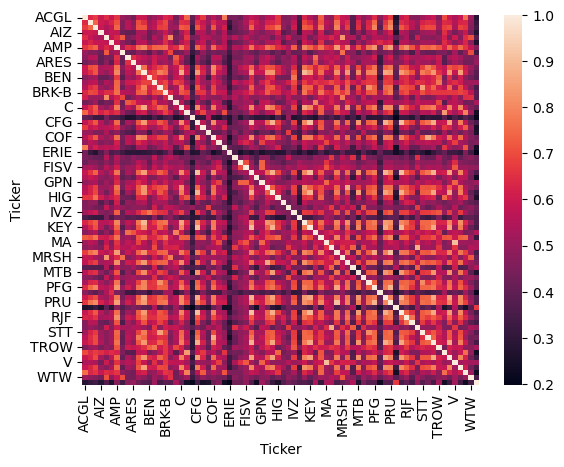

In [3]:
import seaborn as sns
sns.heatmap(returns.corr())

### Standardize + PCA Run

In [4]:
standardized_df = get_standardize_ret(returns)
pca = run_pca(standardized_df)
pc1_weights = pca.components_[0]

### Pick k

In [5]:
import numpy as np
cum_sum = np.cumsum(pca.explained_variance_ratio_)
k = np.argmax(cum_sum >= 0.6) + 1
print(k, cum_sum[:5]) 

2 [0.5616234  0.62726517 0.67108328 0.69093409 0.7081751 ]


Above component 1 alone explains 56%

This explains:
1. One dominant Component explaining >50% variance indicates string market factor

2. This matches expectation of single financials - stocks move together a lot

3. Variance added by component 2 onwards is small (~5-6% each) explaining diminishing returns

### Extract PC1 (*and Sanity Check*)

In [6]:
pc1_weights = pca.components_[0]
pc1_series = pd.Series(pc1_weights, index=returns.columns)
print(pc1_series.sort_values())

Ticker
ERIE    0.067464
CBOE    0.067818
XYZ     0.079564
JKHY    0.080074
PYPL    0.081013
          ...   
MET     0.135548
JPM     0.135823
BAC     0.136653
PRU     0.138634
AMP     0.140277
Length: 74, dtype: float64
